# ASSIGNMENT 8

# Building a Variational Autoencoder and Visualising Its Latent Space

**Name:** Prakruthi BR  
**Course:** BCA  
**Subject:** Generative AI

## Objective

The objective of this assignment is to understand how a Variational Autoencoder (VAE) learns a structured latent space.

In this assignment, the MNIST handwritten digit dataset is used to build and train an Autoencoder and a Variational Autoencoder.

A 2-dimensional latent space is used so that the learned representations can be visualized on a 2D graph.

The assignment also investigates how the VAE reconstructs handwritten digits and generates new digit images from different locations in the latent space.

## Assignment Requirements

The assignment requires the following tasks:

1. Build a Variational Autoencoder using the MNIST dataset.
2. Use a 2-dimensional latent space.
3. Train the VAE for approximately 20 epochs.
4. Record the reconstruction loss.
5. Record the KL-divergence loss.
6. Pass test images through the encoder after training.
7. Plot the resulting 2D latent representations.
8. Colour the latent-space points according to their digit labels from 0 to 9.
9. Select points across the latent space, approximately from -3 to +3.
10. Decode these latent points into digit images.
11. Observe whether similar digits form clusters.
12. Observe whether the clusters are clearly separated.
13. Observe how generated digits change when moving through the latent space.
14. Observe whether the transition between generated images is smooth.

### Implementation Steps

The notebook also includes:

- Importing the required libraries.
- Loading and displaying MNIST data before training.
- Building a normal Autoencoder for comparison.
- Training the normal Autoencoder for 15 epochs.
- Visualizing the Autoencoder latent space.
- Comparing original and reconstructed images.
- Building the VAE encoder, sampling layer and decoder.
- Using MSE reconstruction loss.
- Using KL-divergence loss.
- Recording MSE, KL and total VAE loss.
- Training the VAE for 20 epochs.
- Displaying 20 original and reconstructed test images.
- Visualizing the VAE latent space.
- Generating digits across the latent space from -3 to +3.
- Generating images from extreme latent points outside the commonly observed latent region.

## Step 1: Import Required Libraries

The first step is to import the libraries required for implementing the Autoencoder and Variational Autoencoder.

The following libraries are used:

- NumPy: Used for numerical operations and creating latent-space coordinates.
- Matplotlib: Used for displaying MNIST images, reconstruction results, loss graphs and latent-space plots.
- TensorFlow: Used to build and train the neural networks.
- Keras: Used to create the encoder, decoder, Autoencoder and VAE models.
- Keras Layers: Used to construct the different neural-network layers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

TensorFlow version: 2.20.0
Libraries imported successfully.


## Step 2: Load the MNIST Dataset

The MNIST dataset is a standard dataset used for handwritten digit recognition.

It contains grayscale images of handwritten digits from 0 to 9.

The dataset contains:

- 60,000 training images.
- 10,000 testing images.
- Each image has a size of 28 × 28 pixels.
- Each image contains a handwritten digit from 0 to 9.

The training images will be used to train the Autoencoder and VAE, while the test images will be used to evaluate the learned representations and reconstruction quality.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


## Step 3: Display MNIST Data Before Training

Before training any neural network, the original MNIST images are displayed.

This allows us to understand what the input data looks like before the Autoencoder or Variational Autoencoder has learned anything.

Each image is a handwritten digit, and the corresponding label is displayed above the image.

No training is performed in this step.

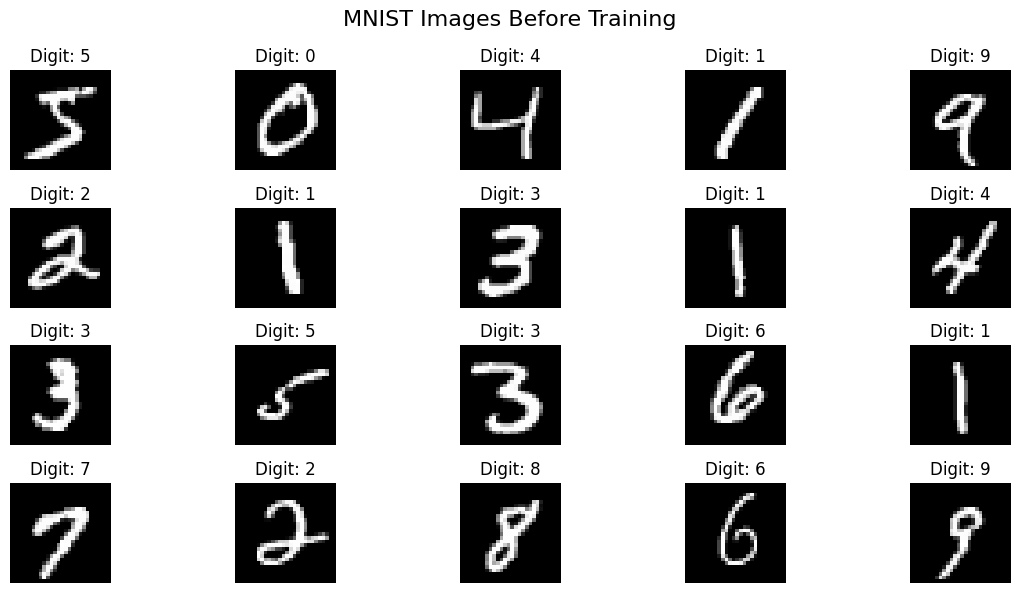

In [3]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Digit: {y_train[i]}")
    plt.axis("off")

plt.suptitle("MNIST Images Before Training", fontsize=16)
plt.tight_layout()
plt.show()

## Step 4: Examine the Pixel Values

The MNIST images contain pixel values between 0 and 255.

A value of 0 represents black, while a value closer to 255 represents white.

Before training the neural networks, the pixel values will be normalized to the range 0 to 1.

Normalization helps the neural network train more effectively.

In [4]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


## Step 5: Normalize and Flatten the MNIST Images

The pixel values are divided by 255 so that they are converted from the range 0–255 to the range 0–1.

The original image has a shape of 28 × 28.

Since the Autoencoder used in this assignment uses fully connected Dense layers, each image is flattened into a vector containing 784 values.

Therefore:

28 × 28 = 784

The final input shape used by the Autoencoder and VAE is 784.

In [5]:
# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten the images
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("Training data shape:", x_train_flat.shape)
print("Testing data shape:", x_test_flat.shape)

print("Minimum normalized value:", x_train_flat.min())
print("Maximum normalized value:", x_train_flat.max())

Training data shape: (60000, 784)
Testing data shape: (10000, 784)
Minimum normalized value: 0.0
Maximum normalized value: 1.0


# Part A: Building a Normal Autoencoder

## Step 6: Understanding the Autoencoder

An Autoencoder is a neural network that learns to compress an input into a smaller representation and then reconstruct the original input.

It consists of two main parts:

### Encoder

The encoder compresses the original 784-dimensional MNIST image into a smaller latent representation.

### Decoder

The decoder takes the latent representation and attempts to reconstruct the original 784-dimensional image.

In this assignment, the latent representation contains only 2 dimensions.

The architecture is:

Input: 784 → Dense Layer: 256 neurons → Dense Layer: 64 neurons → Latent Space: 2 dimensions → Dense Layer: 64 neurons → Dense Layer: 256 neurons →
Output: 784

The 2-dimensional latent representation allows the learned latent space to be visualized on a 2D graph.

## Step 7: Build the Normal Autoencoder Architecture

The encoder gradually reduces the dimensionality of the input:

784 → 256 → 64 → 2

The decoder performs the reverse operation:

2 → 64 → 256 → 784

The final decoder layer uses a sigmoid activation function because the input pixel values have been normalized to the range 0 to 1.

The 2-dimensional output of the encoder represents the latent space of the normal Autoencoder.

In [7]:

# Encoder
encoder_input = keras.Input(
    shape=(784,),
    name="encoder_input"
)

x = layers.Dense(
    256,
    activation="relu"
)(encoder_input)

x = layers.Dense(
    64,
    activation="relu"
)(x)

latent = layers.Dense(
    2,
    name="latent"
)(x)

encoder = keras.Model(
    encoder_input,
    latent,
    name="encoder"
)

# Decoder

decoder_input = keras.Input(
    shape=(2,),
    name="decoder_input"
)

x = layers.Dense(
    64,
    activation="relu"
)(decoder_input)

x = layers.Dense(
    256,
    activation="relu"
)(x)

decoder_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = keras.Model(
    decoder_input,
    decoder_output,
    name="decoder"
)
# Complete Autoencoder
autoencoder_input = keras.Input(
    shape=(784,),
    name="autoencoder_input"
)

encoded = encoder(autoencoder_input)

decoded = decoder(encoded)

autoencoder = keras.Model(
    autoencoder_input,
    decoded,
    name="autoencoder"
)

autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ autoencoder_input (InputLayer)  │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 2)              │       217,538 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       218,320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,858 (1.66 MB)

 Trainable params: 435,858 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Compile the Autoencoder

The Autoencoder needs a loss function and optimizer before training.

Mean Squared Error (MSE) is used as the reconstruction loss.

MSE measures the difference between the original image and the reconstructed image.

A smaller MSE value means that the reconstructed image is closer to the original image.

The Adam optimizer is used to update the network weights during training.

In [8]:
autoencoder.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

print("Autoencoder compiled successfully.")

Autoencoder compiled successfully.


## Step 9: Train the Autoencoder for 15 Epochs

The normal Autoencoder is trained for 15 epochs.

During training, the Autoencoder attempts to reconstruct each MNIST image from its 2-dimensional latent representation.

The original image is used as both:

- Input
- Target output

Therefore, the training objective is:

Input Image → Encoder → 2D Latent Representation → Decoder → Reconstructed Image

The reconstruction error is measured using MSE.

In [9]:
ae_history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=15,
    batch_size=128,
    validation_data=(
        x_test_flat,
        x_test_flat
    ),
    verbose=1
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0636 - val_loss: 0.0523
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0492 - val_loss: 0.0462
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0448 - val_loss: 0.0436
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0428 - val_loss: 0.0421
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0415 - val_loss: 0.0410
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0406 - val_loss: 0.0403
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0400 - val_loss: 0.0398
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0394 - val_loss: 0.0393
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0389 - val_loss: 0.0390
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0385 - val_loss: 0.0385
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0382 - val_loss: 0.0384
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━

## Step 10: Visualize Autoencoder Reconstruction Loss

The Autoencoder training and validation losses are plotted against the number of epochs.

The loss represents the reconstruction error.

A decreasing loss indicates that the Autoencoder is learning to reconstruct the MNIST images more accurately.

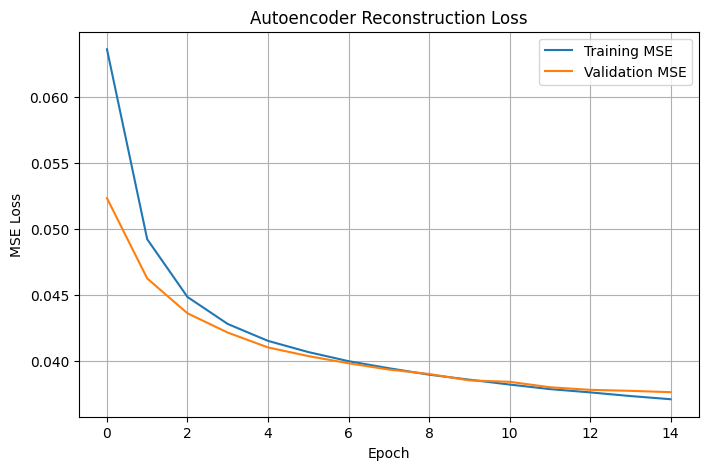

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    ae_history.history["loss"],
    label="Training MSE"
)

plt.plot(
    ae_history.history["val_loss"],
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.show()

## Step 11: Generate the 2D Latent Space of the Autoencoder

After training, the test images are passed through the encoder.

The encoder converts every 784-dimensional test image into a 2-dimensional latent representation.

The resulting points are plotted on a 2D graph.

Each point is coloured according to the actual MNIST digit label from 0 to 9.

This allows us to investigate whether similar digits form groups in the learned latent space.

In [10]:
ae_latent = encoder.predict(
    x_test_flat,
    batch_size=128
)

print("Autoencoder latent representation shape:")
print(ae_latent.shape)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Autoencoder latent representation shape:
(10000, 2)


## Step 12: Visualize the Autoencoder Latent Space

The two latent dimensions are used as the x-axis and y-axis.

The colour represents the digit class:

0, 1, 2, 3, 4, 5, 6, 7, 8 and 9.

The scatter plot allows us to observe how the normal Autoencoder organizes the different handwritten digits.

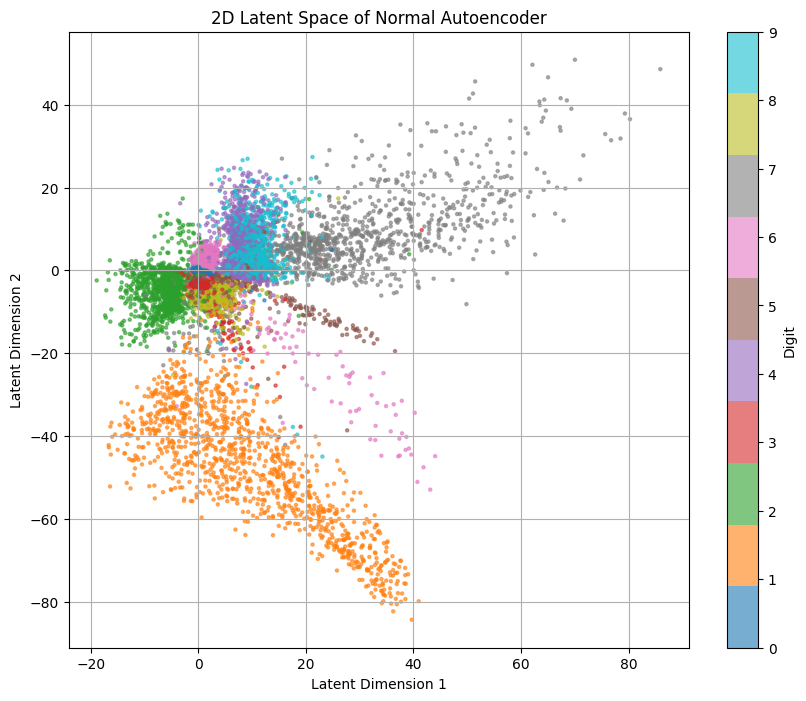

In [12]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    ae_latent[:, 0],
    ae_latent[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D Latent Space of Normal Autoencoder")

plt.grid(True)
plt.show()

## Step 13: Display Original and Reconstructed Images

The trained Autoencoder is used to reconstruct test images.

Twenty test images are selected.

For each image:

- The original MNIST image is displayed.
- The corresponding reconstructed image is displayed.

The reconstruction result shows how much information was preserved after compressing the image into only two latent dimensions.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


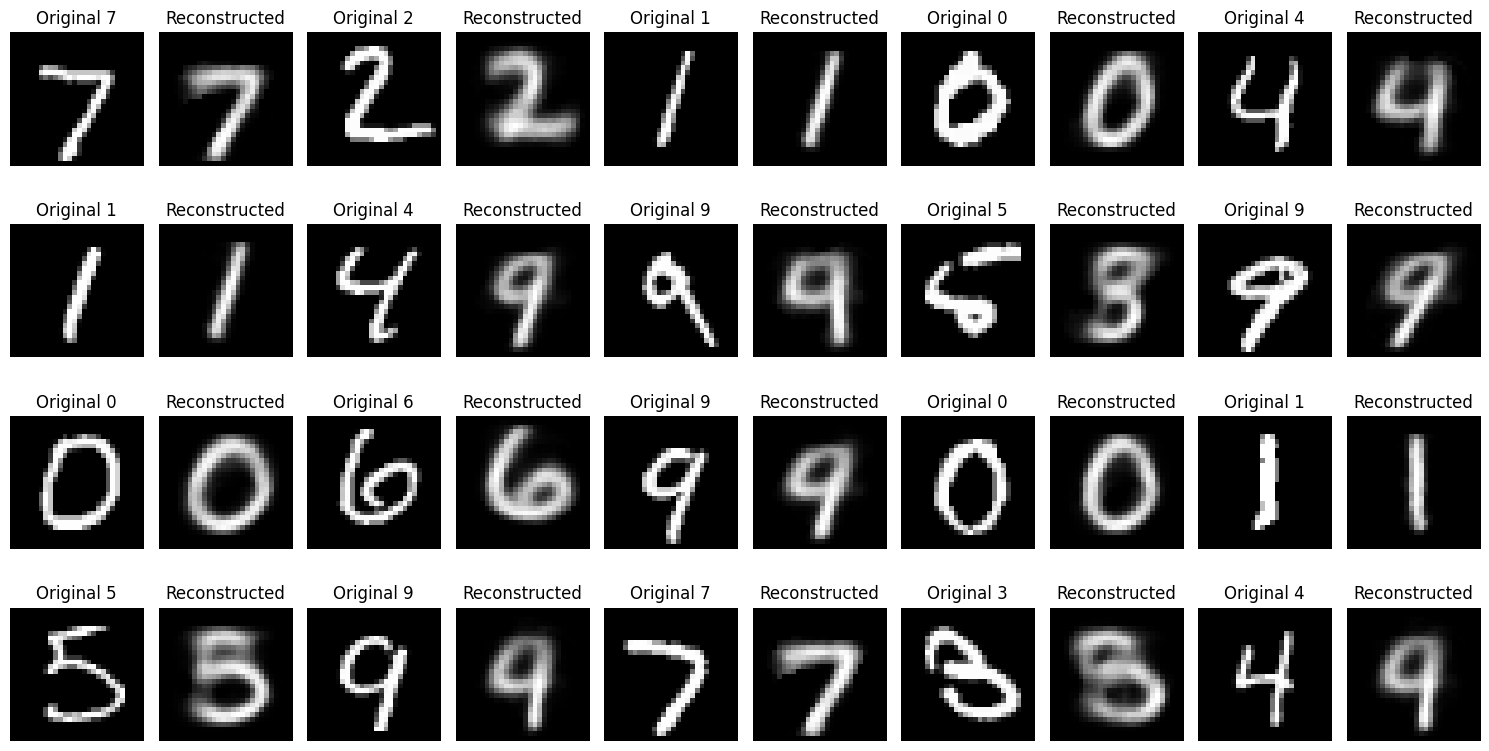

In [13]:
ae_reconstructed = autoencoder.predict(
    x_test_flat[:20]
)

ae_reconstructed = ae_reconstructed.reshape(
    -1,
    28,
    28
)

plt.figure(figsize=(15, 8))

for i in range(20):

    plt.subplot(4, 10, 2 * i + 1)
    plt.imshow(
        x_test[i],
        cmap="gray"
    )
    plt.title(f"Original {y_test[i]}")
    plt.axis("off")

    plt.subplot(4, 10, 2 * i + 2)
    plt.imshow(
        ae_reconstructed[i],
        cmap="gray"
    )
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Part B: Building a Variational Autoencoder

## Step 14: Understanding the Variational Autoencoder

A Variational Autoencoder (VAE) is a generative neural network that learns a structured and continuous latent space.

A normal Autoencoder maps an input image to a fixed latent point.

A VAE instead learns a probability distribution for the latent representation.

The encoder learns two parameters:

1. Mean (μ)
2. Log variance (log σ²)

A latent vector is then sampled from this distribution.

The VAE contains:

Input Image
→
Encoder
→
Mean and Log Variance
→
Sampling
→
2D Latent Vector
→
Decoder
→
Reconstructed Image

The VAE uses two important loss components:

1. Reconstruction loss
2. KL-divergence loss

In this assignment, Mean Squared Error (MSE) is used as the reconstruction loss.

## Step 15: VAE Architecture

The VAE architecture is designed using a 2-dimensional latent space.

### Encoder

The encoder receives a 784-dimensional MNIST image and reduces it through:

784 → 256 → 64

The encoder then produces:

- z_mean
- z_log_var

### Sampling

The sampling layer uses the mean and variance to randomly sample a latent vector z.

### Decoder

The decoder receives the 2-dimensional latent vector and reconstructs the original image:

2 → 64 → 256 → 784

The final output represents the reconstructed MNIST image.

## Step 16: Build the VAE Encoder

The VAE encoder transforms the input MNIST image into two latent parameters.

### z_mean

Represents the mean of the latent probability distribution.

### z_log_var

Represents the logarithm of the variance of the latent distribution.

These two values are used by the sampling layer to generate the latent vector.

In [14]:
latent_dim = 2

vae_encoder_input = keras.Input(
    shape=(784,),
    name="vae_encoder_input"
)

x = layers.Dense(
    256,
    activation="relu"
)(vae_encoder_input)

x = layers.Dense(
    64,
    activation="relu"
)(x)

z_mean = layers.Dense(
    latent_dim,
    name="z_mean"
)(x)

z_log_var = layers.Dense(
    latent_dim,
    name="z_log_var"
)(x)

vae_encoder = keras.Model(
    vae_encoder_input,
    [z_mean, z_log_var],
    name="vae_encoder"
)

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    200,960 │ vae_encoder_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     16,448 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,668 (850.27 KB)

 Trainable params: 217,668 (850.27 KB)

 Non-trainable params: 0 (0.00 B)

## Step 17: Sampling Layer and Reparameterization Trick

The VAE cannot directly sample from the learned distribution in a way that allows normal backpropagation.

Therefore, the reparameterization trick is used.

The latent vector is calculated as:

z = μ + σ × ε

where:

- μ is the learned mean.
- σ is the standard deviation.
- ε is random noise sampled from a standard normal distribution.
- z is the sampled latent vector.

The logarithm of the variance is converted into standard deviation using:

σ = exp(0.5 × log variance)

This sampling process allows the VAE to learn a smooth probabilistic latent space.

In [16]:
class Sampling(layers.Layer):

    def call(self, inputs):

        z_mean, z_log_var = inputs

        epsilon = tf.random.normal(
            shape=tf.shape(z_mean)
        )

        z = (
            z_mean
            + tf.exp(0.5 * z_log_var)
            * epsilon
        )

        return z

## Step 18: Build the VAE Decoder

The decoder receives the 2-dimensional latent vector produced by the sampling layer.

It expands the latent representation back into a 784-dimensional vector.

The architecture is:

2 → 64 → 256 → 784

The final sigmoid activation produces pixel values between 0 and 1.

In [17]:
vae_decoder_input = keras.Input(
    shape=(latent_dim,),
    name="vae_decoder_input"
)

x = layers.Dense(
    64,
    activation="relu"
)(vae_decoder_input)

x = layers.Dense(
    256,
    activation="relu"
)(x)

vae_decoder_output = layers.Dense(
    784,
    activation="sigmoid"
)(x)

vae_decoder = keras.Model(
    vae_decoder_input,
    vae_decoder_output,
    name="vae_decoder"
)

vae_decoder.summary()

Model: "vae_decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vae_decoder_input (InputLayer)  │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,320 (852.81 KB)

 Trainable params: 218,320 (852.81 KB)

 Non-trainable params: 0 (0.00 B)

## Step 19: Connect the VAE Encoder, Sampling Layer and Decoder

The encoder produces the mean and log variance.

The sampling layer uses these values to generate the latent vector.

The decoder then reconstructs the original image from the sampled latent vector.

Therefore, the complete VAE follows:

Input
→
Encoder
→
Mean + Log Variance
→
Sampling
→
2D Latent Vector
→
Decoder
→
Reconstructed Image

In [18]:
z = Sampling()(
    [z_mean, z_log_var]
)

vae_output = vae_decoder(z)

vae = keras.Model(
    vae_encoder_input,
    vae_output,
    name="variational_autoencoder"
)

vae.summary()

Model: "variational_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vae_encoder_input   │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    200,960 │ vae_encoder_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 64)        │     16,448 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vae_decoder         │ (None, 784)       │    218,320 │ sampling[0][0]    │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 435,988 (1.66 MB)

 Trainable params: 435,988 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

## Step 20: Reconstruction Loss Using MSE

The first loss component of the VAE is reconstruction loss.

Mean Squared Error (MSE) measures the difference between the original MNIST image and the reconstructed image.

The formula is:

MSE = mean((Original Image - Reconstructed Image)²)

A lower MSE means that the reconstructed image is closer to the original image.

The reconstruction loss encourages the decoder to preserve the important information from the input image.

In [19]:
def reconstruction_loss(
    y_true,
    y_pred
):

    mse = tf.reduce_mean(
        tf.reduce_sum(
            tf.square(
                y_true - y_pred
            ),
            axis=1
        )
    )

    return mse

## Step 21: KL-Divergence Loss

The second loss component is KL divergence.

KL divergence measures the difference between the learned latent distribution and a standard normal distribution.

The standard normal distribution is:

N(0, 1)

The KL-divergence term encourages the VAE latent space to remain close to this standard normal distribution.

This regularization helps produce a smooth and continuous latent space that can be used for generating new images.

In [20]:
def kl_divergence_loss(
    z_mean,
    z_log_var
):

    kl = -0.5 * tf.reduce_sum(
        1
        + z_log_var
        - tf.square(z_mean)
        - tf.exp(z_log_var),
        axis=1
    )

    return tf.reduce_mean(kl)

## Step 22: Combine MSE and KL Divergence

The VAE uses both reconstruction loss and KL-divergence loss.

The total loss is:

Total VAE Loss
=
MSE Reconstruction Loss
+
KL Divergence Loss

The MSE term helps the model reconstruct the input image.

The KL-divergence term regularizes the latent distribution.

Both losses are recorded separately during training so that their behaviour can be visualized.

## Step 23: Create the Custom VAE Training Model

A custom VAE model is used so that the reconstruction loss and KL-divergence loss can be calculated and recorded separately.

The model contains three important operations:

1. The encoder converts the input image into the latent mean and log variance.
2. The sampling layer produces a latent vector.
3. The decoder reconstructs the original image.

A `call()` method is included so that Keras knows how to perform a normal forward pass through the VAE.

A `test_step()` method is also included so that validation data can be evaluated after every epoch.

In [24]:

class VAE(keras.Model):

    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

        # Track total loss
        self.total_loss_tracker = keras.metrics.Mean(
            name="total_loss"
        )

        # Track reconstruction MSE
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="mse_loss"
        )

        # Track KL divergence
        self.kl_loss_tracker = keras.metrics.Mean(
            name="kl_loss"
        )

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker
        ]


    # Forward pass

    def call(self, inputs, training=False):

        z_mean, z_log_var = self.encoder(
            inputs,
            training=training
        )

        z = self.sampling(
            [z_mean, z_log_var]
        )

        reconstruction = self.decoder(
            z,
            training=training
        )

        return reconstruction


    # Training step

    def train_step(self, data):

        # If Keras provides (x, y), use x
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:

            # Encode
            z_mean, z_log_var = self.encoder(
                data,
                training=True
            )

            # Sample latent vector
            z = self.sampling(
                [z_mean, z_log_var]
            )

            # Reconstruct
            reconstruction = self.decoder(
                z,
                training=True
            )

            # MSE reconstruction loss
            mse_loss = reconstruction_loss(
                data,
                reconstruction
            )

            # KL divergence
            kl_loss = kl_divergence_loss(
                z_mean,
                z_log_var
            )

            # Total loss
            total_loss = mse_loss + kl_loss

        # Calculate gradients
        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Update weights
        self.optimizer.apply_gradients(
            zip(
                gradients,
                self.trainable_weights
            )
        )

        # Update metrics
        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            mse_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "total_loss":
                self.total_loss_tracker.result(),

            "mse_loss":
                self.reconstruction_loss_tracker.result(),

            "kl_loss":
                self.kl_loss_tracker.result()
        }


    # Validation / test step

    def test_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        # Encode
        z_mean, z_log_var = self.encoder(
            data,
            training=False
        )

        # Use the mean during validation
        # for stable reconstruction
        reconstruction = self.decoder(
            z_mean,
            training=False
        )

        # Calculate MSE
        mse_loss = reconstruction_loss(
            data,
            reconstruction
        )

        # Calculate KL divergence
        kl_loss = kl_divergence_loss(
            z_mean,
            z_log_var
        )

        # Total loss
        total_loss = mse_loss + kl_loss

        # Update metrics
        self.total_loss_tracker.update_state(
            total_loss
        )

        self.reconstruction_loss_tracker.update_state(
            mse_loss
        )

        self.kl_loss_tracker.update_state(
            kl_loss
        )

        return {
            "total_loss":
                self.total_loss_tracker.result(),

            "mse_loss":
                self.reconstruction_loss_tracker.result(),

            "kl_loss":
                self.kl_loss_tracker.result()
        }

## Step 24: Compile the Variational Autoencoder

The VAE is compiled using the Adam optimizer.

The optimizer adjusts the neural-network weights to minimize the combined MSE and KL-divergence loss.

Unlike the normal Autoencoder, the VAE loss is calculated inside the custom training step.

In [25]:
vae_model = VAE(
    vae_encoder,
    vae_decoder
)

vae_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    )
)

print("VAE compiled successfully.")

VAE compiled successfully.


## Step 25: Test the VAE Training Pipeline

Before performing the complete 20-epoch training, a single epoch is performed to verify that the custom training and validation steps work correctly.

This prevents us from waiting for all 20 epochs if there is another implementation issue.

In [26]:
test_history = vae_model.fit(
    x_train_flat,
    epochs=1,
    batch_size=128,
    validation_data=(x_test_flat,),
    verbose=1
)

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - kl_loss: 2.8645 - mse_loss: 41.3242 - total_loss: 44.1887 - val_kl_loss: 3.2061 - val_mse_loss: 38.2754 - val_total_loss: 41.4815


## Step 26: Train the VAE for 20 Epochs

The VAE is now trained for the required 20 epochs.

During training, the model learns to reconstruct the MNIST images while simultaneously regularizing the latent distribution using KL divergence.

The following quantities are recorded:

- MSE reconstruction loss
- KL divergence loss
- Total VAE loss
- Validation versions of these losses

In [27]:
# Create a fresh VAE for the final 20-epoch training

vae_model = VAE(
    vae_encoder,
    vae_decoder,
    name="VAE"
)

vae_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    )
)

# Train for exactly 20 epochs
vae_history = vae_model.fit(
    x_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_flat,),
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - kl_loss: 3.4616 - mse_loss: 38.2658 - total_loss: 41.7273 - val_kl_loss: 3.7307 - val_mse_loss: 36.1106 - val_total_loss: 39.8413
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 3.7768 - mse_loss: 36.5838 - total_loss: 40.3606 - val_kl_loss: 3.9577 - val_mse_loss: 34.8887 - val_total_loss: 38.8464
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - kl_loss: 4.0161 - mse_loss: 35.4706 - total_loss: 39.4867 - val_kl_loss: 4.1266 - val_mse_loss: 33.9318 - val_total_loss: 38.0584
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 4.1794 - mse_loss: 34.6696 - total_loss: 38.8490 - val_kl_loss: 4.3676 - val_mse_loss: 33.2914 - val_total_loss: 37.6590
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - kl_loss: 4.3089 - mse_loss: 34.1091 - total_loss: 38.4180 - val_kl_loss: 4.2078 - val_mse_loss: 32.7219 - val_total_loss: 36.9297
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 4.4084 - m

## Step 27: Visualize MSE, KL Divergence and Total Loss

The three recorded loss components are plotted together.

### MSE Reconstruction Loss

Shows how well the VAE reconstructs the original images.

### KL Divergence Loss

Shows the regularization applied to the latent distribution.

### Total Loss

Represents the combination of the reconstruction and KL-divergence losses.

The graph helps us understand how the different loss components behave during the 20 training epochs.

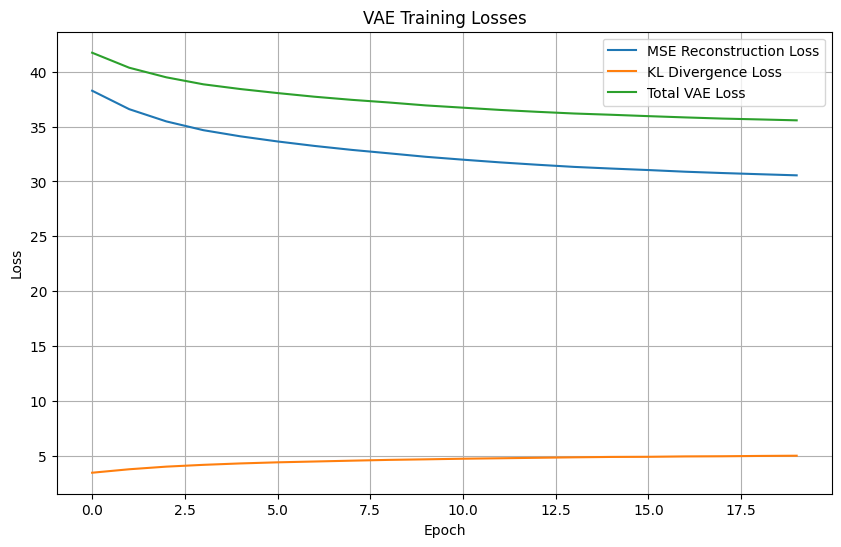

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    vae_history.history["mse_loss"],
    label="MSE Reconstruction Loss"
)

plt.plot(
    vae_history.history["kl_loss"],
    label="KL Divergence Loss"
)

plt.plot(
    vae_history.history["total_loss"],
    label="Total VAE Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")

plt.legend()
plt.grid(True)

plt.show()

## Step 28: Visualize MSE Reconstruction Loss

The MSE reconstruction loss is plotted separately.

This graph shows how the reconstruction error changes over the 20 training epochs.

The reconstruction loss is important because the VAE should generate images that resemble the original MNIST images.

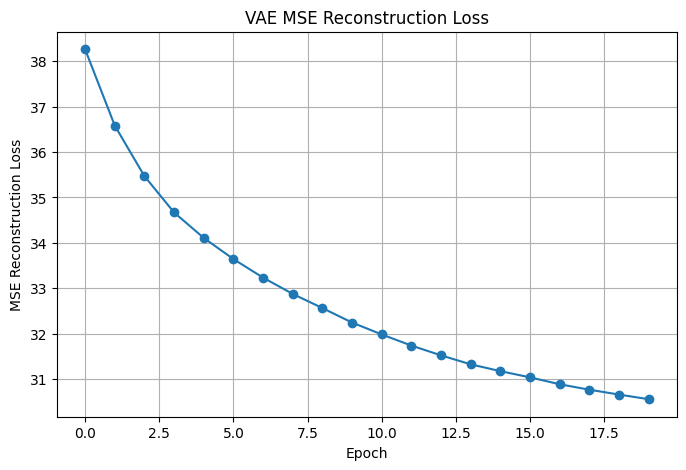

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["mse_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("VAE MSE Reconstruction Loss")

plt.grid(True)
plt.show()

## Step 29: Visualize KL-Divergence Loss

The KL-divergence loss is plotted separately.

The KL term encourages the latent distribution to remain close to a standard normal distribution.

This regularization is one of the major differences between a normal Autoencoder and a Variational Autoencoder.

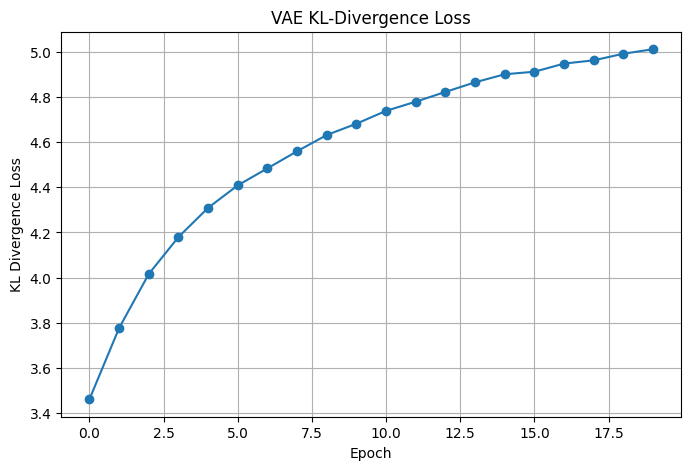

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    vae_history.history["kl_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("KL Divergence Loss")
plt.title("VAE KL-Divergence Loss")

plt.grid(True)
plt.show()

## Step 30: Test the VAE Using 20 Images

After training, 20 test images are passed through the trained VAE.

For each image, two results are displayed:

- Original MNIST image
- VAE reconstructed image

The original images show the actual handwritten digits.

The reconstructed images show what the VAE produces after encoding and decoding the images.

This provides a visual evaluation of reconstruction quality.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


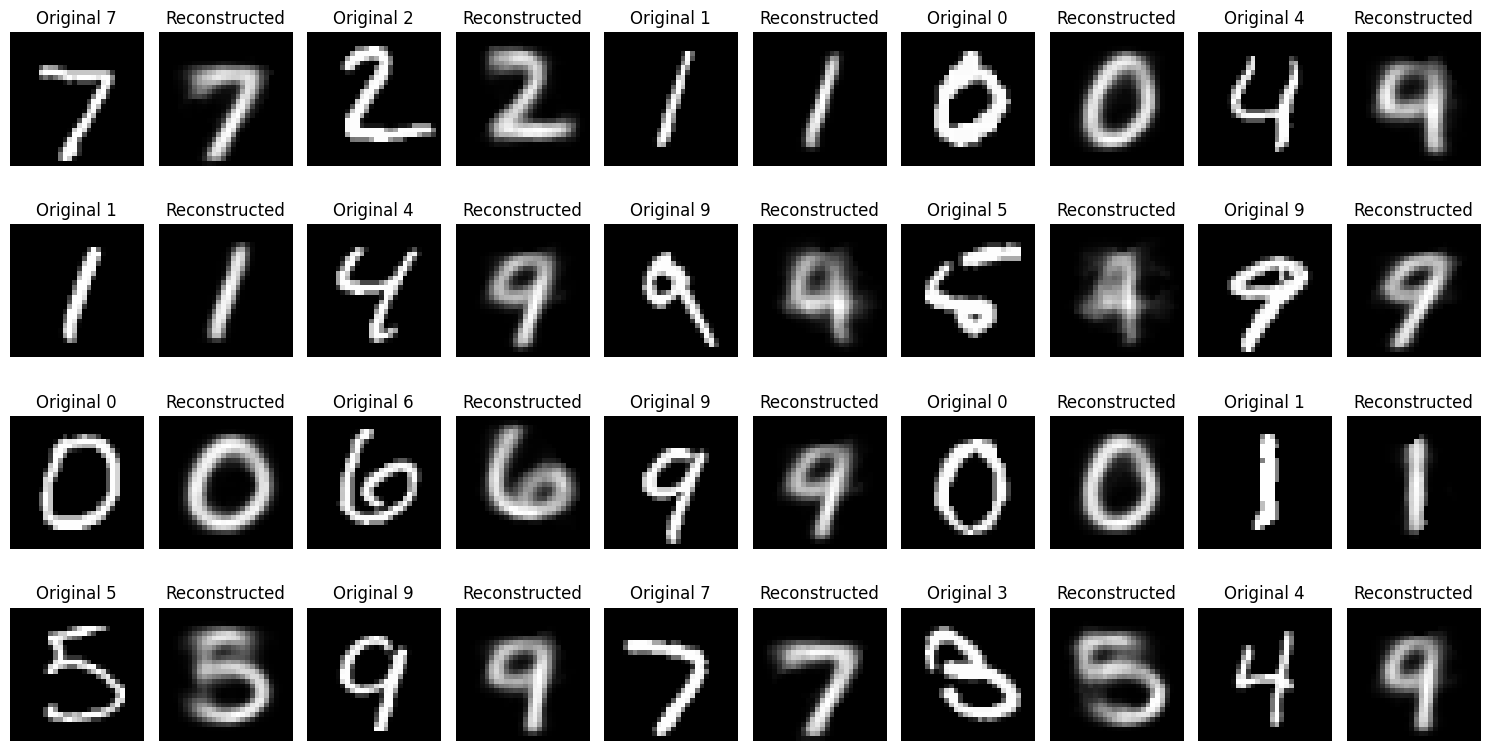

In [33]:
z_mean_test, z_log_var_test = (
    vae_encoder.predict(
        x_test_flat[:20]
    )
)

vae_test_reconstruction = (
    vae_decoder.predict(
        z_mean_test
    )
)

vae_test_reconstruction = (
    vae_test_reconstruction.reshape(
        -1,
        28,
        28
    )
)

plt.figure(figsize=(15, 8))

for i in range(20):

    plt.subplot(4, 10, 2 * i + 1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.title(
        f"Original {y_test[i]}"
    )

    plt.axis("off")

    plt.subplot(
        4,
        10,
        2 * i + 2
    )

    plt.imshow(
        vae_test_reconstruction[i],
        cmap="gray"
    )

    plt.title("Reconstructed")

    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 31: Generate the VAE 2D Latent Representations

After training, all 10,000 test images are passed through the VAE encoder.

The encoder produces a 2-dimensional mean representation for every test image.

The resulting shape should be:

10,000 × 2

This means that every test image has been represented using two latent coordinates.

These coordinates will be visualized in a 2D scatter plot.

In [34]:
z_mean, z_log_var = (
    vae_encoder.predict(
        x_test_flat,
        batch_size=128
    )
)

print(
    "VAE latent representation shape:",
    z_mean.shape
)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
VAE latent representation shape: (10000, 2)


## Step 32: Visualize the VAE Latent Space

The 2D VAE latent space is plotted using:

- Latent Dimension 1 on the x-axis.
- Latent Dimension 2 on the y-axis.

Each point represents one MNIST test image.

The points are coloured according to their actual digit labels from 0 to 9.

This visualization helps answer the assignment questions:

- Do similar digits form clusters?
- Are the clusters clearly separated?
- Do different digit classes overlap?

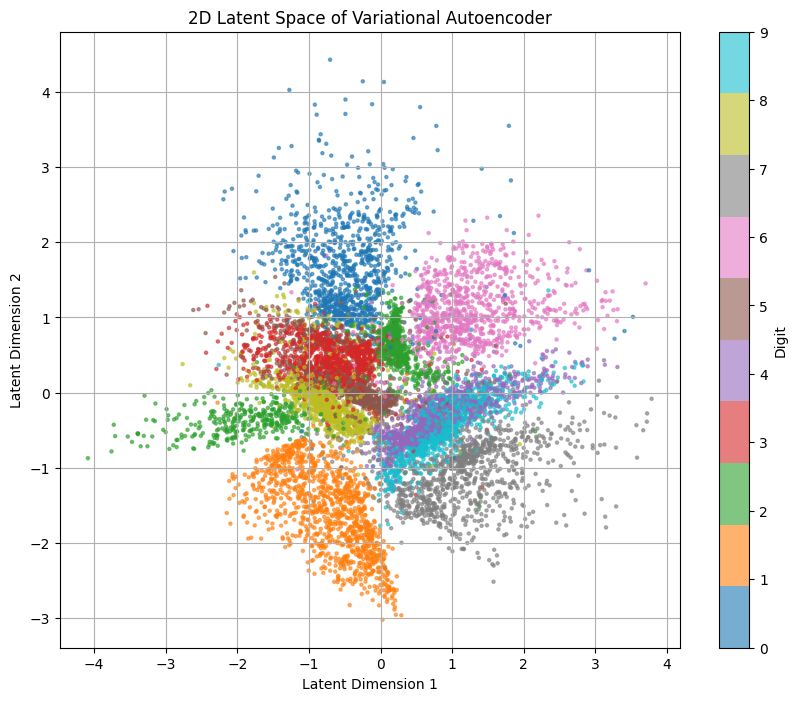

In [35]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    z_mean[:, 0],
    z_mean[:, 1],
    c=y_test,
    cmap="tab10",
    s=5,
    alpha=0.6
)

plt.colorbar(
    scatter,
    ticks=range(10),
    label="Digit"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.title(
    "2D Latent Space of Variational Autoencoder"
)

plt.grid(True)

plt.show()

## Step 33: Examine the Observed Latent-Space Range

Before generating new digits, the minimum and maximum values observed in the test latent representations are calculated.

This helps us understand the region where the test data is actually represented.

The commonly observed region can then be compared with deliberately extreme points such as (-6, -6) and (6, 6).

In [36]:
print("Latent Dimension 1:")
print(
    "Minimum:",
    z_mean[:, 0].min()
)
print(
    "Maximum:",
    z_mean[:, 0].max()
)

print("\nLatent Dimension 2:")
print(
    "Minimum:",
    z_mean[:, 1].min()
)
print(
    "Maximum:",
    z_mean[:, 1].max()
)

Latent Dimension 1:
Minimum: -4.0870433
Maximum: 3.7861733

Latent Dimension 2:
Minimum: -3.0200675
Maximum: 4.4276953


## Step 34: Generate Digits Across the VAE Latent Space

One of the main advantages of a VAE is that new images can be generated by selecting points in the latent space and passing them through the decoder.

The assignment asks us to select points across the latent space, for example from -3 to +3.

Therefore, a grid of latent coordinates is created from -3 to +3 for both latent dimensions.

Each selected latent coordinate is passed through the decoder to generate a digit image.

This allows us to observe how the generated digits change as we move through the latent space.

In [37]:
grid_size = 15

z1 = np.linspace(
    -3,
    3,
    grid_size
)

z2 = np.linspace(
    -3,
    3,
    grid_size
)

generated_images = []

for y in z2[::-1]:

    for x in z1:

        z_point = np.array(
            [[x, y]],
            dtype=np.float32
        )

        decoded = vae_decoder.predict(
            z_point,
            verbose=0
        )

        generated_images.append(
            decoded[0].reshape(
                28,
                28
            )
        )

generated_images = np.array(
    generated_images
)

print(
    "Number of generated images:",
    len(generated_images)
)

Number of generated images: 225


## Step 35: Display the Decoded Image Grid

The generated images are arranged into a grid.

Each image corresponds to a different point in the VAE latent space.

The grid covers latent coordinates from approximately -3 to +3.

This visualization demonstrates the generative ability of the VAE.

By moving horizontally or vertically through the grid, we can observe gradual changes in the generated digit shapes.

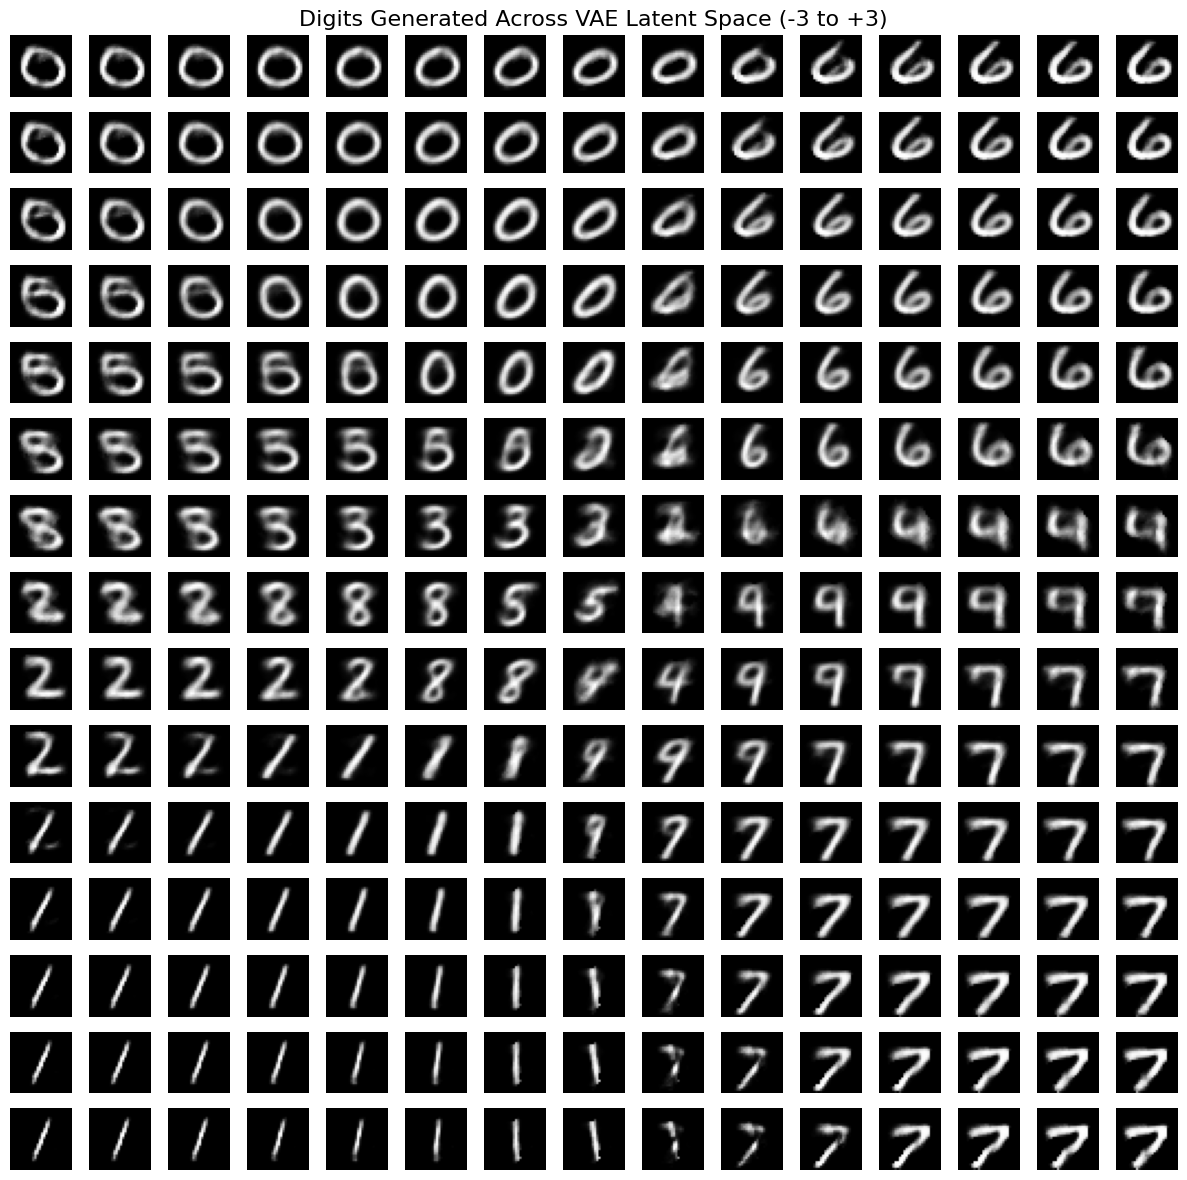

In [38]:
plt.figure(figsize=(12, 12))

for i in range(
    grid_size * grid_size
):

    plt.subplot(
        grid_size,
        grid_size,
        i + 1
    )

    plt.imshow(
        generated_images[i],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Digits Generated Across VAE Latent Space (-3 to +3)",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Step 36: Generate Images from Extreme Latent Points

The assignment also investigates what happens when points are selected outside the commonly observed latent region.

The VAE is encouraged through KL divergence to organize its latent distribution approximately around a standard normal distribution.

Therefore, points such as:

(-6, -6)
(-6, 6)
(6, -6)
(6, 6)

are far into the tails of the distribution.

These points are deliberately selected to investigate how the decoder behaves when it receives latent coordinates far from the central region where the test data is concentrated.

The point (0, 0) is included as a central reference point.

In [39]:
extreme_points = np.array(
    [
        [0, 0],
        [-6, -6],
        [-6, 6],
        [6, -6],
        [6, 6]
    ],
    dtype=np.float32
)

extreme_images = (
    vae_decoder.predict(
        extreme_points,
        verbose=0
    )
)

extreme_images = (
    extreme_images.reshape(
        -1,
        28,
        28
    )
)

## Step 37: Visualize Images Generated from Extreme Points

The images generated from the extreme latent coordinates are displayed.

The central point (0, 0) represents a point near the center of the latent distribution.

The ±6 points represent extreme latent coordinates.

Images generated at extreme points may be less recognizable or distorted because these locations are far from the commonly observed data region.

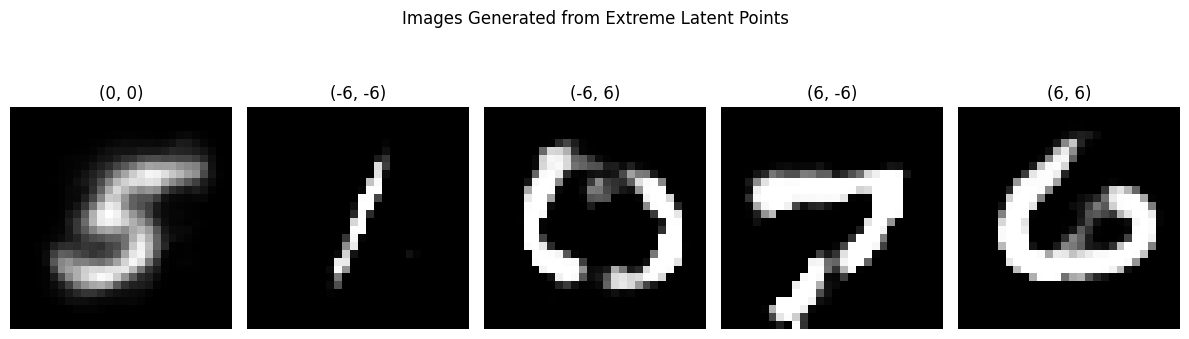

In [40]:
plt.figure(figsize=(12, 4))

for i in range(
    len(extreme_points)
):

    plt.subplot(
        1,
        5,
        i + 1
    )

    plt.imshow(
        extreme_images[i],
        cmap="gray"
    )

    plt.title(
        f"({extreme_points[i, 0]:.0f}, "
        f"{extreme_points[i, 1]:.0f})"
    )

    plt.axis("off")

plt.suptitle(
    "Images Generated from Extreme Latent Points"
)

plt.tight_layout()
plt.show()

## Step 38: Compare Normal and Extreme Latent Points

To better understand the effect of moving away from the central latent region, several points are compared.

The selected points include:

- (0, 0): central latent point.
- (3, 3): within the requested generation range.
- (-3, -3): within the requested generation range.
- (6, 6): extreme point.
- (-6, -6): extreme point.

The generated images allow us to visually compare the results from commonly sampled and extreme latent coordinates.

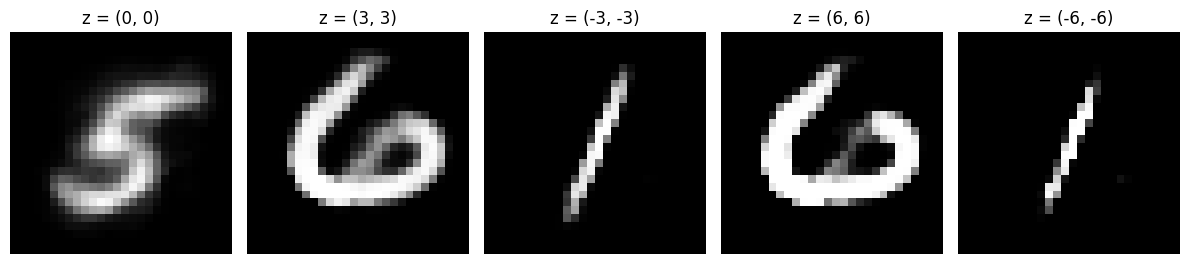

In [41]:
comparison_points = np.array(
    [
        [0, 0],
        [3, 3],
        [-3, -3],
        [6, 6],
        [-6, -6]
    ],
    dtype=np.float32
)

comparison_images = (
    vae_decoder.predict(
        comparison_points,
        verbose=0
    )
)

comparison_images = (
    comparison_images.reshape(
        -1,
        28,
        28
    )
)

plt.figure(figsize=(12, 3))

for i in range(
    len(comparison_points)
):

    plt.subplot(
        1,
        5,
        i + 1
    )

    plt.imshow(
        comparison_images[i],
        cmap="gray"
    )

    plt.title(
        f"z = ({comparison_points[i,0]:.0f}, "
        f"{comparison_points[i,1]:.0f})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# Observations

## Do similar digits form clusters?

The 2D VAE latent-space scatter plot shows that images belonging to the same digit class tend to occupy nearby regions of the latent space. However, the clusters are not expected to be perfectly separated because handwritten digits can have different writing styles and some digits have visually similar structures.

## Are the clusters clearly separated?

Some digit classes form relatively distinct regions, while other classes overlap. The amount of overlap depends on the learned representation and the randomness involved during neural-network training.

## How do generated digits change when moving gradually through the latent space?

The generated digit images generally change gradually when moving from one nearby latent point to another. Changes may be observed in properties such as digit shape, thickness, orientation and writing style.

## Does the transition between generated images appear smooth?

The transition is generally smooth because the VAE encourages the latent representations to follow a continuous probability distribution. Nearby latent points therefore tend to produce related images.

## What happens at extreme latent points?

When the decoder receives extreme latent coordinates far outside the commonly observed region, the generated images may become distorted, unclear or less recognizable. This happens because such regions contain very few encoded training examples.

## What is the role of MSE reconstruction loss?

MSE measures the difference between the original image and the reconstructed image. It encourages the VAE to reconstruct the input MNIST images accurately.

## What is the role of KL divergence?

KL divergence regularizes the learned latent distribution so that it remains close to a standard normal distribution. This helps create a smooth and continuous latent space suitable for generation.

## What is the difference between an Autoencoder and a VAE?

A normal Autoencoder maps an input image to a fixed latent representation. A VAE learns a probability distribution represented using a mean and variance and samples latent vectors from this distribution.

Because of this probabilistic structure, a VAE can generate new images by sampling different points from the latent space.

# Conclusion

A normal Autoencoder and a Variational Autoencoder were implemented using the MNIST handwritten digit dataset.

The normal Autoencoder compressed the 784-dimensional MNIST images into a 2-dimensional latent representation and reconstructed the original images.

The Variational Autoencoder extended this approach by learning a probability distribution in the latent space using a mean and log variance. The reparameterization trick was used to sample latent vectors.

The VAE was trained using two main loss components:

1. MSE reconstruction loss
2. KL-divergence loss

The total VAE loss was calculated as:

Total Loss = MSE Reconstruction Loss + KL Divergence Loss

The loss curves were visualized separately and together.

The trained VAE was then used to:

- Reconstruct 20 test images.
- Visualize the 2D latent representations.
- Colour the latent points according to digit labels 0–9.
- Generate new digits from points ranging from approximately -3 to +3.
- Visualize a decoded image grid.
- Generate images from extreme latent points outside the commonly observed latent region.

The latent-space visualization demonstrates how the VAE organizes handwritten digits into a continuous representation. Moving through the latent space produces gradual changes in the generated digits, while extreme points may produce less recognizable images.